### Caricamento Dati

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("ai_student_impact_dataset.csv")

data.drop("Student_ID", axis=1, inplace=True)
data.drop("Post_Semester_GPA", axis=1, inplace=True)

TARGET = "Skill_Retention_Score"
print(data.shape)
data.head()

(50000, 14)


,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Skill_Retention_Score,Burnout_Risk_Level
0,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,86.44,High
1,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,69.39,Low
2,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,73.93,Medium
3,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,63.58,Medium
4,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,100.00,Medium


In [2]:
display(pd.DataFrame({"Tipo": data.dtypes, "Non nulli": data.notna().sum(), "Nulli": data.isna().sum()}))
# display(data.describe())

data.select_dtypes([np.number]).corr()[TARGET].sort_values()

,Tipo,Non nulli,Nulli
Major_Category,str,50000,0
Year_of_Study,str,50000,0
Pre_Semester_GPA,float64,50000,0
Weekly_GenAI_Hours,float64,50000,0
Primary_Use_Case,str,50000,0
Prompt_Engineering_Skill,str,50000,0
Tool_Diversity,int64,50000,0
Paid_Subscription,bool,50000,0
Traditional_Study_Hours,float64,50000,0
Perceived_AI_Dependency,int64,50000,0


Weekly_GenAI_Hours           -0.118099
Perceived_AI_Dependency      -0.084324
Anxiety_Level_During_Exams   -0.041556
Pre_Semester_GPA              0.099019
Traditional_Study_Hours       0.147565
Tool_Diversity                0.196952
Skill_Retention_Score         1.000000
Name: Skill_Retention_Score, dtype: float64

### Grafici

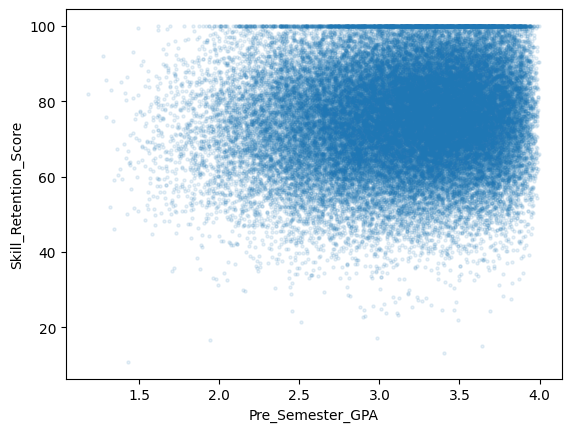

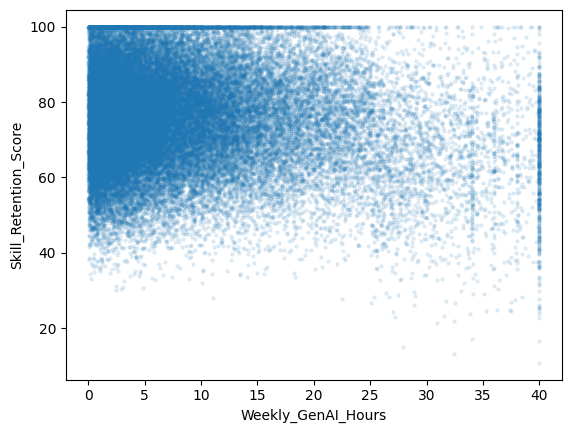

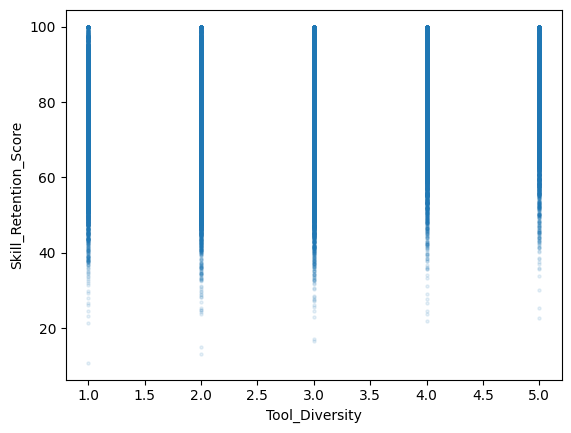

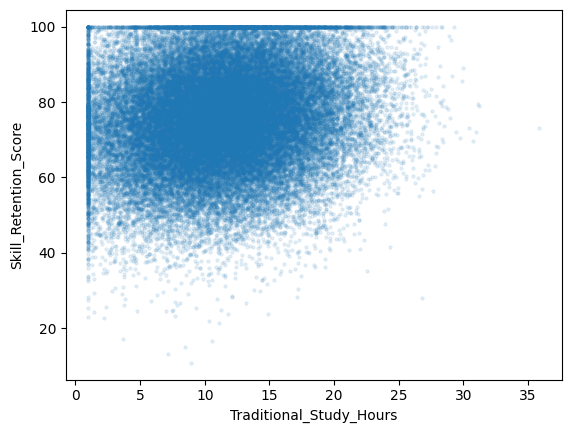

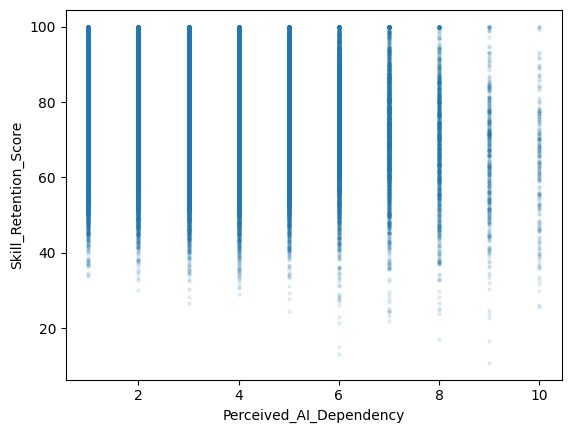

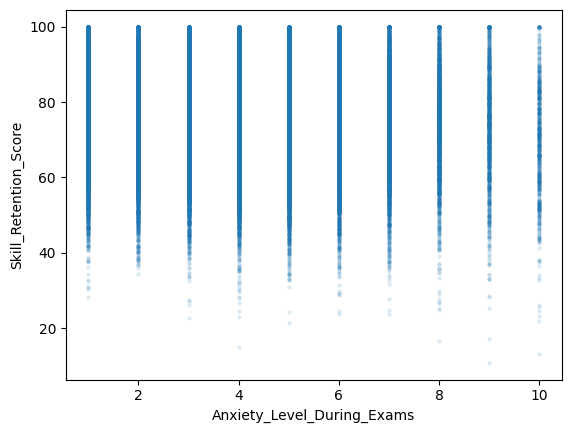

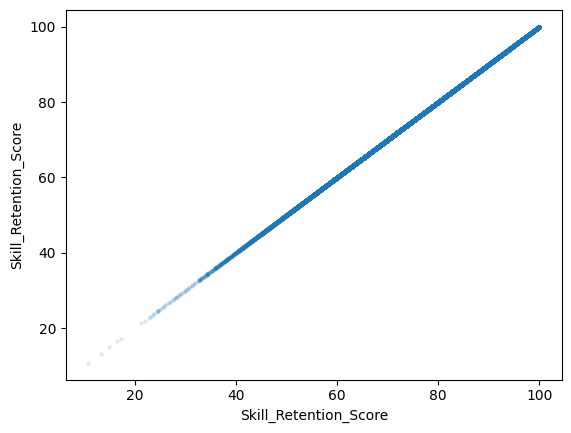

array([[<Axes: title={'center': 'Pre_Semester_GPA'}>,
        <Axes: title={'center': 'Weekly_GenAI_Hours'}>,
        <Axes: title={'center': 'Tool_Diversity'}>],
       [<Axes: title={'center': 'Traditional_Study_Hours'}>,
        <Axes: title={'center': 'Perceived_AI_Dependency'}>,
        <Axes: title={'center': 'Anxiety_Level_During_Exams'}>],
       [<Axes: title={'center': 'Skill_Retention_Score'}>, <Axes: >,
        <Axes: >]], dtype=object)

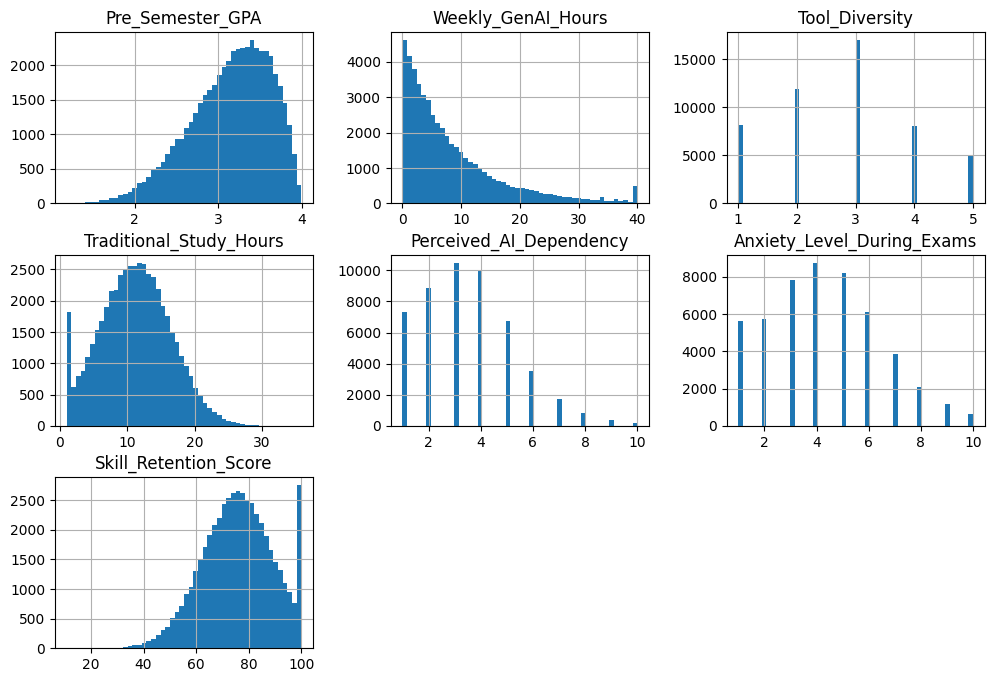

In [3]:
for f in data.select_dtypes([np.number]):
    plt.scatter(data[f], data[TARGET], alpha=0.1, s=5)
    plt.xlabel(f); plt.ylabel(TARGET)
    plt.show()

data.hist(bins=50, figsize=(12, 8))

### Split Train/Test

In [4]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(data, test_size=0.2, random_state=42)

X_train = train_set.drop(TARGET, axis=1)
y_train = train_set[TARGET].copy()

X_test = test_set.drop(TARGET, axis=1)
y_test = test_set[TARGET].copy()

print(f"Train: {X_train.shape} \nTest: {X_test.shape}")

Train: (40000, 13) 
Test: (10000, 13)


### Pipeline di Preprocessing

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = X_train.select_dtypes(include=[np.number, bool]).columns
cat_cols = X_train.select_dtypes(include=["str"]).columns

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),                        
    ("scaler", StandardScaler())                                       
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),   
    ("onehot", OneHotEncoder(sparse_output=False))                        
])

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols),
])

X_train_prep = preprocessing.fit_transform(X_train)                  
X_test_prep = preprocessing.transform(X_test)                           

print(f"Shape dopo preprocessing: {X_train_prep.shape}")

Shape dopo preprocessing: (40000, 31)


### Random Forest con GridSearchCV

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_features': [4, 6, 8, 10],
}

grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_prep, y_train)

print(f"Migliori parametri: {grid_search.best_params_}")
print(f"Miglior CV RMSE: {-grid_search.best_score_}")

best_rf = grid_search.best_estimator_

Migliori parametri: {'max_features': 8, 'n_estimators': 200}
Miglior CV RMSE: 11.888207863488297


### Valutazione sul Test Set

In [7]:
from sklearn.metrics import root_mean_squared_error

preds_rf = best_rf.predict(X_test_prep)

rmse_rf = root_mean_squared_error(y_test, preds_rf)

print(f"RMSE: {rmse_rf}")
print(f"Errore relativo: {rmse_rf / (y_train.max() - y_train.min()) * 100}%")

RMSE: 11.866048758044377
Errore relativo: 13.299763234750477%


### Preparazione Dati per PyTorch

In [12]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_t = torch.FloatTensor(X_train_prep)
X_test_t = torch.FloatTensor(X_test_prep)
y_train_t = torch.FloatTensor(y_train.values).view(-1, 1)
y_test_t = torch.FloatTensor(y_test.values).view(-1, 1)

y_mean = y_train_t.mean()
y_std = y_train_t.std()
y_train_s = (y_train_t - y_mean) / y_std
y_test_s = (y_test_t - y_mean) / y_std

train_dataset = TensorDataset(X_train_t, y_train_s)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

print(f"Batches per epoca: {len(train_loader)}")

Batches per epoca: 313


### Definizione e Training del Modello

In [9]:
import torch.nn as nn

torch.manual_seed(42)

def training_minibatch(model, opt, loss_fn, n_epochs=25):
    for epoch in range(n_epochs):
        total_loss = 0                         
        for X_batch, y_batch in train_loader:
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)       
            loss.backward()                       
            opt.step()                             
            opt.zero_grad()                     
            total_loss += loss.item()
        print(f"Epoch {epoch + 1}/{n_epochs}, loss: {total_loss / len(train_loader)}")

mlp_model = nn.Sequential(nn.Linear(X_train_t.shape[1], 50), nn.ReLU(), nn.Linear(50, 40), nn.ReLU(), nn.Linear(40, 1))
optimizer = torch.optim.SGD(mlp_model.parameters(), lr=0.01)
mse = nn.MSELoss()
training_minibatch(mlp_model, optimizer, mse)       

Epoch 1/25, loss: 0.9833714539250626
Epoch 2/25, loss: 0.9101550101091306
Epoch 3/25, loss: 0.8560283711543099
Epoch 4/25, loss: 0.835006615414787
Epoch 5/25, loss: 0.8240133228774269
Epoch 6/25, loss: 0.8183690623734325
Epoch 7/25, loss: 0.813859267927968
Epoch 8/25, loss: 0.8103829997416121
Epoch 9/25, loss: 0.8074708285803993
Epoch 10/25, loss: 0.80417457175331
Epoch 11/25, loss: 0.8015850892843911
Epoch 12/25, loss: 0.7988474481402875
Epoch 13/25, loss: 0.7960341602278213
Epoch 14/25, loss: 0.7940479516983032
Epoch 15/25, loss: 0.791619696746619
Epoch 16/25, loss: 0.7900418170724814
Epoch 17/25, loss: 0.7878701437395602
Epoch 18/25, loss: 0.7871383192440191
Epoch 19/25, loss: 0.7859137903768033
Epoch 20/25, loss: 0.7853557006619609
Epoch 21/25, loss: 0.783807204363826
Epoch 22/25, loss: 0.7831013749201838
Epoch 23/25, loss: 0.7830544026514974
Epoch 24/25, loss: 0.7824476488862937
Epoch 25/25, loss: 0.7818922981286582


### Valutazione sul Test Set

In [10]:
with torch.no_grad():                               
    preds_mlp_s = mlp_model(X_test_t)             
preds_mlp = (preds_mlp_s * y_std + y_mean) 

rmse_mlp = root_mean_squared_error(y_test, preds_mlp)

print(f"RMSE: {rmse_mlp}")
print(f"Errore relativo: {rmse_mlp / (y_train.max() - y_train.min()) * 100}%")

RMSE: 11.809767072029524
Errore relativo: 13.236681318123205%


### Confronto

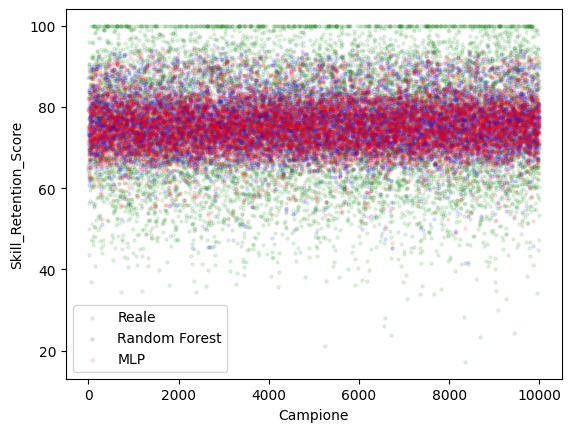

Random Forest                                MLP             \
          Reale  Predetto Errore_Relativo_%  Reale   Predetto   
0         23.31  63.98525        174.496997  17.22  50.272255   
1         21.25  54.81020        157.930353  23.31  64.165207   
2         17.22  41.50390        141.021487  21.25  53.444733   
3         23.86  56.55220        137.016764  23.86  55.053764   
4         24.42  52.62275        115.490377  28.19  61.735069   

                     
  Errore_Relativo_%  
0        191.941086  
1        175.269013  
2        151.504624  
3        130.736649  
4        118.996344

In [11]:
preds_mlp_np = preds_mlp.numpy().ravel() 
x_idx = np.arange(len(y_test))

plt.scatter(x_idx, y_test.values, alpha=0.1, s=5, c='green', label='Reale')
plt.scatter(x_idx, preds_rf, alpha=0.1, s=5, c='blue', label='Random Forest')
plt.scatter(x_idx, preds_mlp_np, alpha=0.1, s=5, c='red', label='MLP')
plt.xlabel("Campione"); plt.ylabel("Skill_Retention_Score")
plt.legend(); plt.show()

def top_errors(preds):
    err = pd.DataFrame({"Reale": y_test.values, "Predetto": preds})
    err["Errore_Relativo_%"] = np.abs(err["Reale"] - err["Predetto"]) / err["Reale"] * 100
    return err.nlargest(5, "Errore_Relativo_%").reset_index(drop=True)

display(pd.concat([top_errors(preds_rf), top_errors(preds_mlp_np)], axis=1, keys=["Random Forest", "MLP"]))